# V2 Research: OHLCV Primitives + Alpha101 + 变换树 + CatBoost

**目标**：H=20 截面选股，观察各特征的单因子有效性，与 v1（XGBoost, 52 Alpha101 原始特征）对比。

流程：
1. 数据加载
2. 构建 primitives（OHLCV + Alpha101）
3. 变换层（一阶 + 二阶 + 交叉组合）
4. **单因子 IC 分析**（哪些特征有效）
5. Walk-forward CatBoost 训练
6. OOS 结果 + Feature Importance
7. 与 v1 基线对比

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

# Add project root to path so `sp500_relative_alpha` is importable
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sp500_relative_alpha.alpha101_features import compute_alpha101_feature_matrices
from sp500_relative_alpha.alpha101_ops import build_alpha101_input_matrices
from sp500_relative_alpha.catboost_models import CatBoostRegressorConfig, CatBoostRegressorPredictor
from sp500_relative_alpha.daily_data_loader import ROUND1_SNAPSHOT_MANIFEST, load_round1_daily_ohlcv
from sp500_relative_alpha.feature_transforms import CrossCombinationSpec, TransformConfig, compute_feature_frame
from sp500_relative_alpha.folds import build_round1_walk_forward_folds, validate_fold_label_windows
from sp500_relative_alpha.metrics import RankICConfig, evaluate_oos_rank_ic
from sp500_relative_alpha.modeling import WalkForwardPredictionConfig, run_walk_forward_predictions
from sp500_relative_alpha.ohlcv_features import compute_ohlcv_feature_matrices
from sp500_relative_alpha.research_dataset import build_v2_research_dataset

HORIZON = 20
EXCLUDED_SYMBOLS = ("HUBB",)

%matplotlib inline
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True

## 1. 数据加载

In [2]:
manifest = pd.read_csv(ROUND1_SNAPSHOT_MANIFEST)
load_symbols = [s for s in manifest["symbol"].tolist() if s not in EXCLUDED_SYMBOLS]

daily_bars = load_round1_daily_ohlcv(symbols=load_symbols)
print(f"rows={len(daily_bars):,}  symbols={daily_bars['symbol'].nunique()}  "
      f"date_range=[{daily_bars['date'].min().date()}, {daily_bars['date'].max().date()}]")

rows=1,375,565  symbols=503  date_range=[2015-01-02, 2026-03-31]


## 2. 构建 Primitives

In [3]:
# OHLCV primitives
ohlcv_primitives = compute_ohlcv_feature_matrices(daily_bars)
print(f"OHLCV primitives: {len(ohlcv_primitives)}")
print(" ", list(ohlcv_primitives.keys()))

# Alpha101 primitives
alpha_inputs = build_alpha101_input_matrices(daily_bars)
alpha_raw = compute_alpha101_feature_matrices(alpha_inputs)
alpha_primitives = {f"alpha_{k}": v for k, v in alpha_raw.items()}
print(f"\nAlpha101 primitives: {len(alpha_primitives)}")

all_primitives = {**ohlcv_primitives, **alpha_primitives}
print(f"\nTotal primitives: {len(all_primitives)}")

OHLCV primitives: 25
  ['ret_1d', 'ret_5d', 'ret_10d', 'ret_20d', 'ret_60d', 'ret_120d', 'ret_252d', 'intraday_ret', 'overnight_gap', 'close_position', 'high_low_range', 'log_volume', 'volume_ratio_20d', 'volume_ratio_60d', 'excess_ret_lag1d', 'excess_ret_lag2d', 'excess_ret_lag5d', 'excess_ret_lag10d', 'excess_ret_lag20d', 'excess_ret_mean5d', 'excess_ret_std5d', 'excess_ret_mean21d', 'excess_ret_std21d', 'excess_ret_mean63d', 'excess_ret_std63d']

Alpha101 primitives: 52

Total primitives: 77


## 3. 变换层

配置变换树，查看最终特征数量。

In [5]:
CROSS_COMBINATIONS = (
    CrossCombinationSpec("ret_20d", "volume_ratio_20d", "mul", "ret20d_x_volr20d"),
    CrossCombinationSpec("ret_60d", "volume_ratio_60d", "mul", "ret60d_x_volr60d"),
    CrossCombinationSpec("ret_20d", "high_low_range",   "sub", "ret20d_sub_hlr"),
    CrossCombinationSpec("ret_60d", "high_low_range",   "sub", "ret60d_sub_hlr"),
    CrossCombinationSpec("ret_5d",  "ret_60d",          "sub", "ret5d_sub_ret60d"),
    CrossCombinationSpec("ret_20d", "ret_252d",         "sub", "ret20d_sub_ret252d"),
    CrossCombinationSpec("close_position", "volume_ratio_20d", "mul", "closepos_x_volr20d"),
)

TRANSFORM_CONFIG = TransformConfig(
    keep_identity=True,
    apply_cs_rank=True,
    ts_zscore_windows=(20, 60, 120),
    ts_change_windows=(5, 20, 60),
    apply_second_order=True,
    cross_combinations=CROSS_COMBINATIONS,
    output_prefix="feat_",
)

# 预估特征数量（不跑计算）
n_primitives = len(all_primitives)
n_per_primitive = (
    (1 if TRANSFORM_CONFIG.keep_identity else 0)
    + (1 if TRANSFORM_CONFIG.apply_cs_rank else 0)
    + len(TRANSFORM_CONFIG.ts_zscore_windows)
    + len(TRANSFORM_CONFIG.ts_change_windows)
)
n_second_order = (
    len(TRANSFORM_CONFIG.ts_zscore_windows)   # csr∘tsz
    + len(TRANSFORM_CONFIG.ts_change_windows) # csr∘tc
    + len(TRANSFORM_CONFIG.ts_zscore_windows) # tsz∘csr
    + len(TRANSFORM_CONFIG.ts_change_windows) # tc∘csr
) if TRANSFORM_CONFIG.apply_second_order else 0

estimated_features = n_primitives * (n_per_primitive + n_second_order) + len(CROSS_COMBINATIONS)
print(f"Primitives       : {n_primitives}")
print(f"Per-primitive    : {n_per_primitive} (1st order) + {n_second_order} (2nd order) = {n_per_primitive + n_second_order}")
print(f"Cross-combos     : {len(CROSS_COMBINATIONS)}")
print(f"Estimated total  : ~{estimated_features} features")

Primitives       : 77
Per-primitive    : 8 (1st order) + 12 (2nd order) = 20
Cross-combos     : 7
Estimated total  : ~1547 features


## 4. 构建数据集 H=20

In [8]:
dataset = build_v2_research_dataset(
    daily_bars,
    horizons=[HORIZON],
    transform_config=TRANSFORM_CONFIG,
)
h_samples = dataset[dataset["horizon"] == HORIZON].copy().reset_index(drop=True)
feat_cols = sorted(c for c in h_samples.columns if c.startswith("feat_"))
label_col = "benchmark_relative_open_to_open_return"

print(f"Dataset rows    : {len(h_samples):,}")
print(f"Symbols         : {h_samples['symbol'].nunique()}")
print(f"Signal dates    : {h_samples['signal_date'].nunique()}")
print(f"Feature columns : {len(feat_cols)}")

# NaN coverage per feature category
categories = {
    "identity":    [c for c in feat_cols if not any(s in c for s in ["_csr","_tsz","_tc"])],
    "cs_rank":     [c for c in feat_cols if c.endswith("_csr") and "_tsz" not in c and "_tc" not in c],
    "ts_zscore":   [c for c in feat_cols if "_tsz" in c and not c.endswith("_csr")],
    "ts_change":   [c for c in feat_cols if "_tc" in c and not c.endswith("_csr")],
    "2nd_order":   [c for c in feat_cols if (c.endswith("_csr") and ("_tsz" in c or "_tc" in c))
                    or ("_csr_tsz" in c) or ("_csr_tc" in c)],
}
print("\nFeature counts by category:")
for cat, cols in categories.items():
    print(f"  {cat:12s}: {len(cols)}")

/Users/hsy/Work/Invest/sp500_relative_alpha/feature_transforms.py:226: RuntimeWarning: invalid value encountered in subtract
  result[window:] = (mat[window:] - mat[:-window]).astype(np.float32)


Dataset rows    : 1,225,807
Symbols         : 502
Signal dates    : 2515
Feature columns : 1547

Feature counts by category:
  identity    : 84
  cs_rank     : 77
  ts_zscore   : 462
  ts_change   : 462
  2nd_order   : 924


## 5. 单因子 IC 分析

对每个特征单独计算截面 Rank IC（与 H=20 标签的 Spearman 相关），评估哪些特征有独立预测力。

方法：每个交易日，计算该特征值与标签的截面排名相关，然后汇总每日 IC 序列。

In [9]:
def compute_univariate_ic(samples: pd.DataFrame, feature_cols: list[str], label_col: str) -> pd.DataFrame:
    """
    Vectorized rank IC for all features.

    Strategy: pivot each feature to date×symbol, rank cross-sectionally,
    then use corrwith() against the label ranks. Much faster than groupby loops.
    """
    # Label ranks: date × symbol matrix
    label_wide = samples.pivot(index="signal_date", columns="symbol", values=label_col)
    label_ranks = label_wide.rank(axis=1, pct=True)

    rows = []
    for col in feature_cols:
        feat_wide = samples.pivot(index="signal_date", columns="symbol", values=col)
        feat_ranks = feat_wide.rank(axis=1, pct=True, na_option="keep")
        # Pearson on ranks = Spearman; corrwith computes row-wise correlation
        daily_ic = feat_ranks.corrwith(label_ranks, axis=1).dropna()
        if len(daily_ic) == 0:
            continue
        rows.append({
            "feature":       col,
            "mean_ic":       daily_ic.mean(),
            "ic_std":        daily_ic.std(),
            "icir":          daily_ic.mean() / daily_ic.std() if daily_ic.std() > 0 else 0.0,
            "positive_rate": (daily_ic > 0).mean(),
            "n_days":        len(daily_ic),
        })

    return (
        pd.DataFrame(rows)
        .sort_values("mean_ic", ascending=False)
        .reset_index(drop=True)
    )

print("Function defined. Run next cell to compute IC for all features (~1-2 min).")

Function defined. Run next cell to compute IC for all features (~1-2 min).


In [10]:
ic_df = compute_univariate_ic(h_samples, feat_cols, label_col)
print(f"IC computed for {len(ic_df)} features")
print(f"\nIC 分布统计:")
print(ic_df["mean_ic"].describe().to_string())

IC computed for 1547 features

IC 分布统计:
count    1547.000000
mean        0.000657
std         0.006127
min        -0.027296
25%        -0.001961
50%         0.001382
75%         0.004043
max         0.025859


In [8]:
# Top 30 特征：按 mean IC 排名
print("=== Top 30 features by mean IC ===")
print(ic_df.head(30).to_string(index=False))

print("\n=== Bottom 20 features (weakest / negative IC) ===")
print(ic_df.tail(20).to_string(index=False))

=== Top 30 features by mean IC ===
                  feature  mean_ic   ic_std     icir  positive_rate  n_days
      feat_high_low_range 0.025859 0.161484 0.160136       0.559046    2515
  feat_high_low_range_csr 0.025859 0.161484 0.160135       0.559046    2515
    feat_alpha_026_tsz120 0.017527 0.259239 0.067611       0.514115    2515
feat_alpha_026_tsz120_csr 0.017527 0.259239 0.067611       0.514115    2515
feat_alpha_026_csr_tsz120 0.017269 0.260071 0.066401       0.514115    2515
    feat_alpha_024_tsz120 0.014042 0.124326 0.112948       0.546569    2448
feat_alpha_024_tsz120_csr 0.014042 0.124326 0.112948       0.546569    2448
           feat_alpha_039 0.013891 0.146368 0.094905       0.529622    2515
       feat_alpha_039_csr 0.013891 0.146368 0.094904       0.529622    2515
           feat_alpha_024 0.013583 0.119979 0.113212       0.545924    2515
       feat_alpha_024_csr 0.013548 0.119923 0.112974       0.546720    2515
feat_alpha_038_tsz120_csr 0.013525 0.141719 0.095438 

In [9]:
# 按特征类别分组：哪一类变换平均 IC 更高
def feature_category(name: str) -> str:
    if "_tsz" in name and "_csr" not in name:
        return "ts_zscore"
    if "_tc" in name and name.endswith("_csr") and "_tsz" not in name:
        return "tc_csr (2nd)"
    if "_tc" in name and "_csr" not in name:
        return "ts_change"
    if "_tsz" in name and name.endswith("_csr"):
        return "tsz_csr (2nd)"
    if "_csr_tsz" in name:
        return "csr_tsz (2nd)"
    if "_csr_tc" in name:
        return "csr_tc (2nd)"
    if name.endswith("_csr"):
        return "cs_rank"
    return "identity"

ic_df["category"] = ic_df["feature"].apply(feature_category)

cat_summary = (
    ic_df.groupby("category")["mean_ic"]
    .agg(["mean", "median", "count", lambda x: (x > 0).mean()])
    .rename(columns={"<lambda_0>": "pct_positive"})
    .sort_values("mean", ascending=False)
)
print("=== IC 按变换类别汇总 ===")
print(cat_summary.to_string())

=== IC 按变换类别汇总 ===
                   mean    median  count  pct_positive
category                                              
cs_rank        0.002356  0.003094     66      0.742424
csr_tsz (2nd)  0.001613  0.002722    198      0.727273
tsz_csr (2nd)  0.001536  0.002411    198      0.686869
ts_zscore      0.001535  0.002411    198      0.686869
csr_tc (2nd)   0.001145  0.001410    198      0.717172
tc_csr (2nd)   0.001066  0.001563    198      0.691919
ts_change      0.001063  0.001618    198      0.696970
identity       0.000914  0.003036     73      0.684932


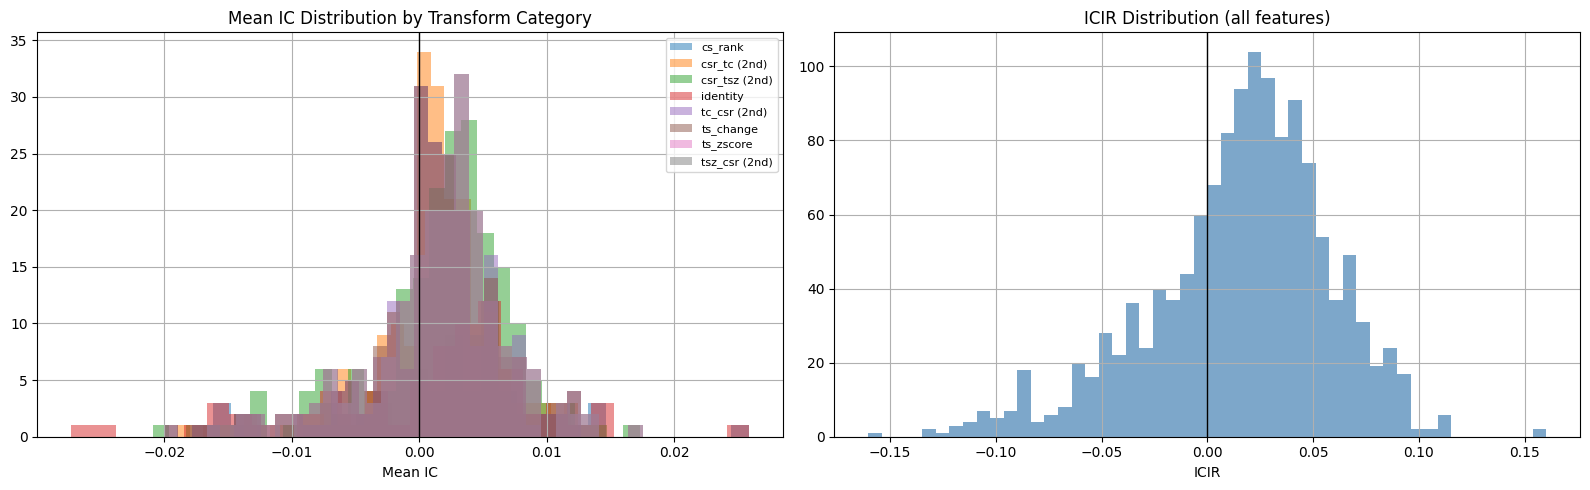

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: mean IC 分布直方图（按类别着色）
colors = plt.cm.tab10.colors
for i, (cat, group) in enumerate(ic_df.groupby("category")):
    axes[0].hist(group["mean_ic"], bins=30, alpha=0.5, label=cat, color=colors[i % 10])
axes[0].axvline(0, color="k", lw=1)
axes[0].set_title("Mean IC Distribution by Transform Category")
axes[0].set_xlabel("Mean IC")
axes[0].legend(fontsize=8)

# Right: ICIR 分布
ic_df_filtered = ic_df[ic_df["icir"].between(-3, 3)]  # clip extremes for viz
axes[1].hist(ic_df_filtered["icir"], bins=50, color="steelblue", alpha=0.7)
axes[1].axvline(0, color="k", lw=1)
axes[1].set_title("ICIR Distribution (all features)")
axes[1].set_xlabel("ICIR")

plt.tight_layout()
plt.show()

In [11]:
# OHLCV vs Alpha101：哪个来源的特征 IC 更强
ic_df["source"] = ic_df["feature"].apply(
    lambda x: "alpha101" if "_alpha_" in x else ("cross_combo" if any(
        x == f"feat_{s.name}" for s in CROSS_COMBINATIONS) else "ohlcv")
)
source_summary = (
    ic_df.groupby("source")["mean_ic"]
    .agg(["mean", "median", "count", lambda x: (x > 0).mean()])
    .rename(columns={"<lambda_0>": "pct_positive"})
    .sort_values("mean", ascending=False)
)
print("=== IC 按特征来源（OHLCV vs Alpha101）===")
print(source_summary.to_string())

=== IC 按特征来源（OHLCV vs Alpha101）===
                 mean    median  count  pct_positive
source                                              
alpha101     0.003186  0.002875   1040      0.854808
ohlcv       -0.005084 -0.004533    280      0.150000
cross_combo -0.013149 -0.014266      7      0.142857


## 6. Walk-Forward 训练（CatBoost）

In [16]:
signal_dates = h_samples["signal_date"].drop_duplicates()
folds = build_round1_walk_forward_folds(signal_dates)
validate_fold_label_windows(h_samples, folds)
print(f"Folds: {len(folds)}, label window validation passed")
for fold in folds:
    print(f"  {fold.fold_id}: train [{fold.train_start.date()}→{fold.train_end.date()}]  "
          f"test [{fold.test_start.date()}→{fold.test_end.date()}]")

Folds: 5, label window validation passed
  fold_001: train [2015-12-31→2020-01-02]  test [2020-03-31→2020-09-28]
  fold_002: train [2015-12-31→2020-09-28]  test [2020-12-23→2021-06-24]
  fold_003: train [2015-12-31→2021-06-24]  test [2021-09-21→2022-03-21]
  fold_004: train [2015-12-31→2022-03-21]  test [2022-06-16→2022-12-14]
  fold_005: train [2015-12-31→2022-12-14]  test [2023-03-15→2023-09-13]


In [17]:
cb_config = CatBoostRegressorConfig()

prediction_config = WalkForwardPredictionConfig(feature_prefix="feat_", n_top_features=200)

n_top = prediction_config.n_top_features or len(feat_cols)
print(f"Feature pool: {len(feat_cols)}  →  per-fold top-{n_top} by IC  |  folds: {len(folds)}")
predictions = run_walk_forward_predictions(
    h_samples,
    folds,
    lambda: CatBoostRegressorPredictor(cb_config),
    config=prediction_config,
)
print(f"Prediction rows: {len(predictions):,}")

Feature pool: 1547  →  per-fold top-200 by IC  |  folds: 5
Prediction rows: 310,547


## 7. OOS 结果

In [18]:
panel, fold_summary, horizon_summary = evaluate_oos_rank_ic(predictions, folds, RankICConfig())

print("=== Fold-level Rank IC (v2 CatBoost) ===")
print(fold_summary[["fold_id","mean_rank_ic","positive_rate","icir","hac_t_stat","p_value_one_sided"]].to_string(index=False))

row = horizon_summary[horizon_summary["horizon"] == HORIZON].iloc[0]
print(f"\n=== H={HORIZON} Overall ===")
print(f"  mean Rank IC : {row['mean_rank_ic']:.4f}")
print(f"  positive rate: {row['positive_rate']:.2%}")
print(f"  ICIR         : {row['icir']:.3f}")
print(f"  HAC t-stat   : {row['hac_t_stat']:.3f}")
print(f"  p (one-sided): {row['p_value_one_sided']:.4f}")
print(f"  bootstrap CI : [{row['bootstrap_ci_lower']:.4f}, {row['bootstrap_ci_upper']:.4f}]")

=== Fold-level Rank IC (v2 CatBoost) ===
 fold_id  mean_rank_ic  positive_rate      icir  hac_t_stat  p_value_one_sided
fold_001      0.056373       0.579365  0.313705    1.748753           0.040167
fold_002      0.054391       0.682540  0.321473    1.833016           0.033400
fold_003     -0.066976       0.349206 -0.468918   -2.804233           0.997478
fold_004      0.020249       0.563492  0.118196    0.656946           0.255608
fold_005      0.029136       0.507937  0.257327    1.437196           0.075331

=== H=20 Overall ===
  mean Rank IC : 0.0186
  positive rate: 53.65%
  ICIR         : 0.114
  HAC t-stat   : 1.257
  p (one-sided): 0.1043
  bootstrap CI : [-0.0210, 0.0591]


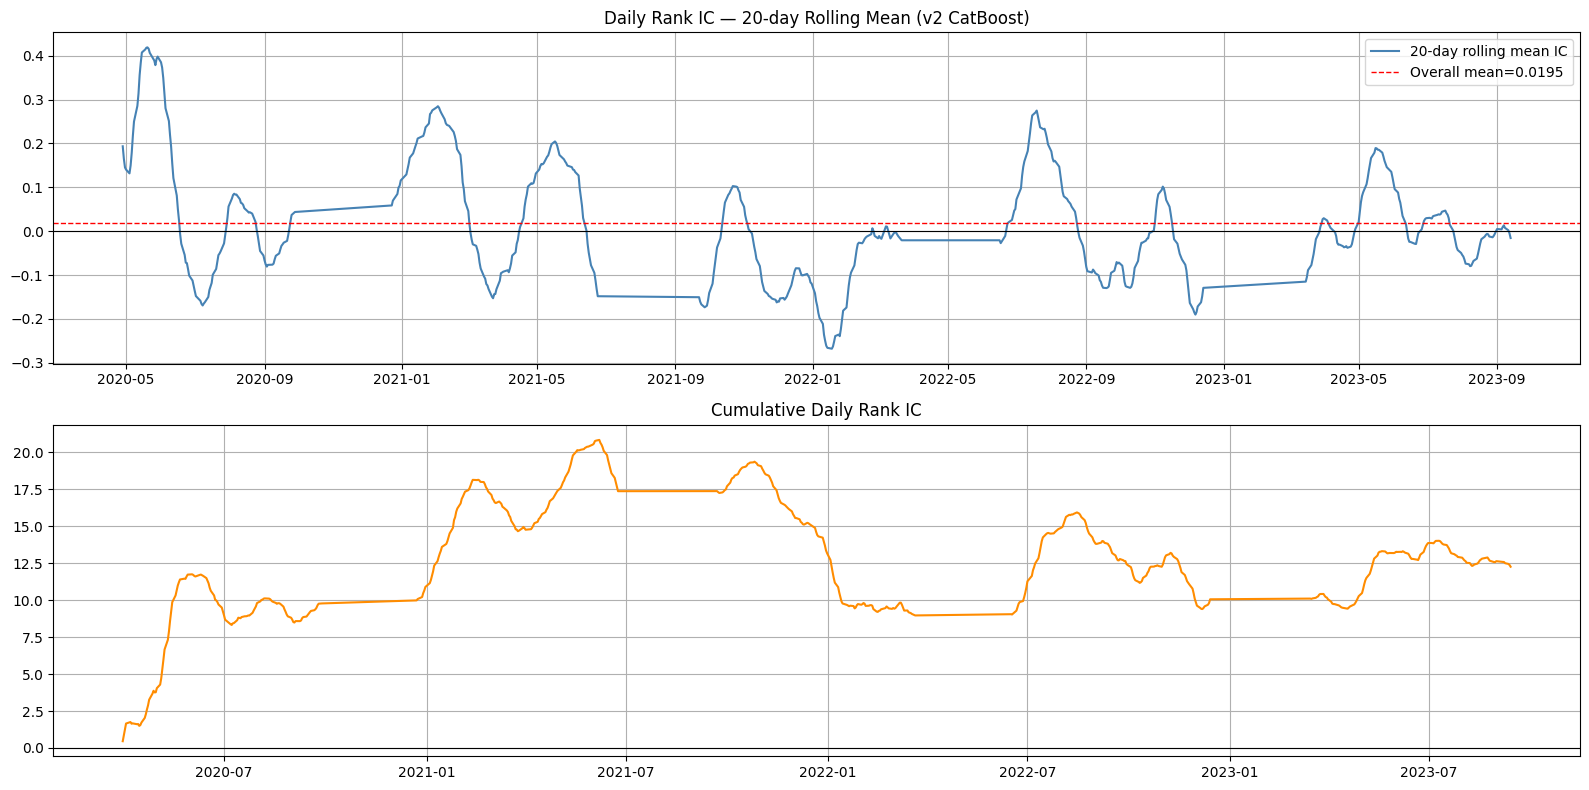

In [15]:
# 每日 IC 时间序列
daily_ic = panel[panel["horizon"] == HORIZON].set_index("signal_date")["rank_ic"]

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

axes[0].plot(daily_ic.index, daily_ic.rolling(20).mean(), label="20-day rolling mean IC", color="steelblue")
axes[0].axhline(0, color="k", lw=0.8)
axes[0].axhline(daily_ic.mean(), color="red", lw=1, linestyle="--", label=f"Overall mean={daily_ic.mean():.4f}")
axes[0].set_title("Daily Rank IC — 20-day Rolling Mean (v2 CatBoost)")
axes[0].legend()

axes[1].plot(daily_ic.index, daily_ic.cumsum(), color="darkorange")
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_title("Cumulative Daily Rank IC")

plt.tight_layout()
plt.show()

## 8. Feature Importance

在 **第一个 fold 的训练集** 上单独拟合一个 CatBoost，提取 feature importance。
（仅用于分析，不影响 OOS 评估结果。）

In [16]:
from sp500_relative_alpha.folds import fold_period_mask
from sp500_relative_alpha.modeling import _select_top_features_by_ic
from catboost import CatBoostRegressor

fold0 = folds[0]
train_mask = fold_period_mask(h_samples, fold0, "train")
train_df = h_samples.loc[train_mask]

# Same per-fold IC selection as the actual OOS model
n_top = prediction_config.n_top_features or len(feat_cols)
fold0_feat_cols = list(_select_top_features_by_ic(
    train_df, tuple(feat_cols), label_col, n_top
))
print(f"fold_001 selected {len(fold0_feat_cols)} features")

src_counts = pd.Series(fold0_feat_cols).apply(
    lambda x: "alpha101" if "_alpha_" in x else (
        "cross_combo" if any(x == f"feat_{s.name}" for s in CROSS_COMBINATIONS) else "ohlcv")
).value_counts()
print(f"Source breakdown of selected features:\n{src_counts.to_string()}\n")

y_train = train_df[label_col].to_numpy(dtype=float)
valid = np.isfinite(y_train)
x_train = train_df.loc[valid, fold0_feat_cols].apply(pd.to_numeric, errors="coerce")

cb_fi = CatBoostRegressor(
    iterations=cb_config.iterations,
    depth=cb_config.depth,
    learning_rate=cb_config.learning_rate,
    l2_leaf_reg=cb_config.l2_leaf_reg,
    min_data_in_leaf=cb_config.min_data_in_leaf,
    random_seed=cb_config.random_seed,
    thread_count=cb_config.thread_count,
    verbose=0,
    allow_writing_files=False,
)
cb_fi.fit(x_train, y_train[valid])

fi_series = pd.Series(cb_fi.get_feature_importance(), index=fold0_feat_cols).sort_values(ascending=False)
fi_df = fi_series.reset_index()
fi_df.columns = ["feature", "importance"]
fi_df["category"] = fi_df["feature"].apply(feature_category)
fi_df["source"] = fi_df["feature"].apply(
    lambda x: "alpha101" if "_alpha_" in x else (
        "cross_combo" if any(x == f"feat_{s.name}" for s in CROSS_COMBINATIONS) else "ohlcv")
)

print(f"=== Top 30 features by CatBoost importance (fold_001, {n_top}-feature model) ===")
print(fi_df.head(30).to_string(index=False))

fold_001 selected 200 features
Source breakdown of selected features:
alpha101       116
ohlcv           80
cross_combo      4

=== Top 30 features by CatBoost importance (fold_001, 200-feature model) ===
                  feature  importance      category   source
            feat_ret_252d   11.148228      identity    ohlcv
             feat_ret_60d    8.956279      identity    ohlcv
        feat_ret_60d_tc60    4.991527     ts_change    ohlcv
        feat_ret_252d_csr    4.485784       cs_rank    ohlcv
    feat_ret_60d_tc60_csr    3.593444  tc_csr (2nd)    ohlcv
  feat_ret_60d_csr_tsz120    3.136849 csr_tsz (2nd)    ohlcv
       feat_ret_252d_tc60    3.065471     ts_change    ohlcv
      feat_high_low_range    2.647967      identity    ohlcv
             feat_ret_20d    2.532260      identity    ohlcv
   feat_ret_60d_csr_tsz60    2.347133 csr_tsz (2nd)    ohlcv
        feat_ret_20d_tc20    2.301168     ts_change    ohlcv
         feat_ret_60d_csr    2.036820       cs_rank    ohlcv
  

/var/folders/cr/c6d4b6wd28g75zdm8ppqqrv00000gn/T/ipykernel_44501/390911685.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(cat_fi.index, rotation=30, ha="right")


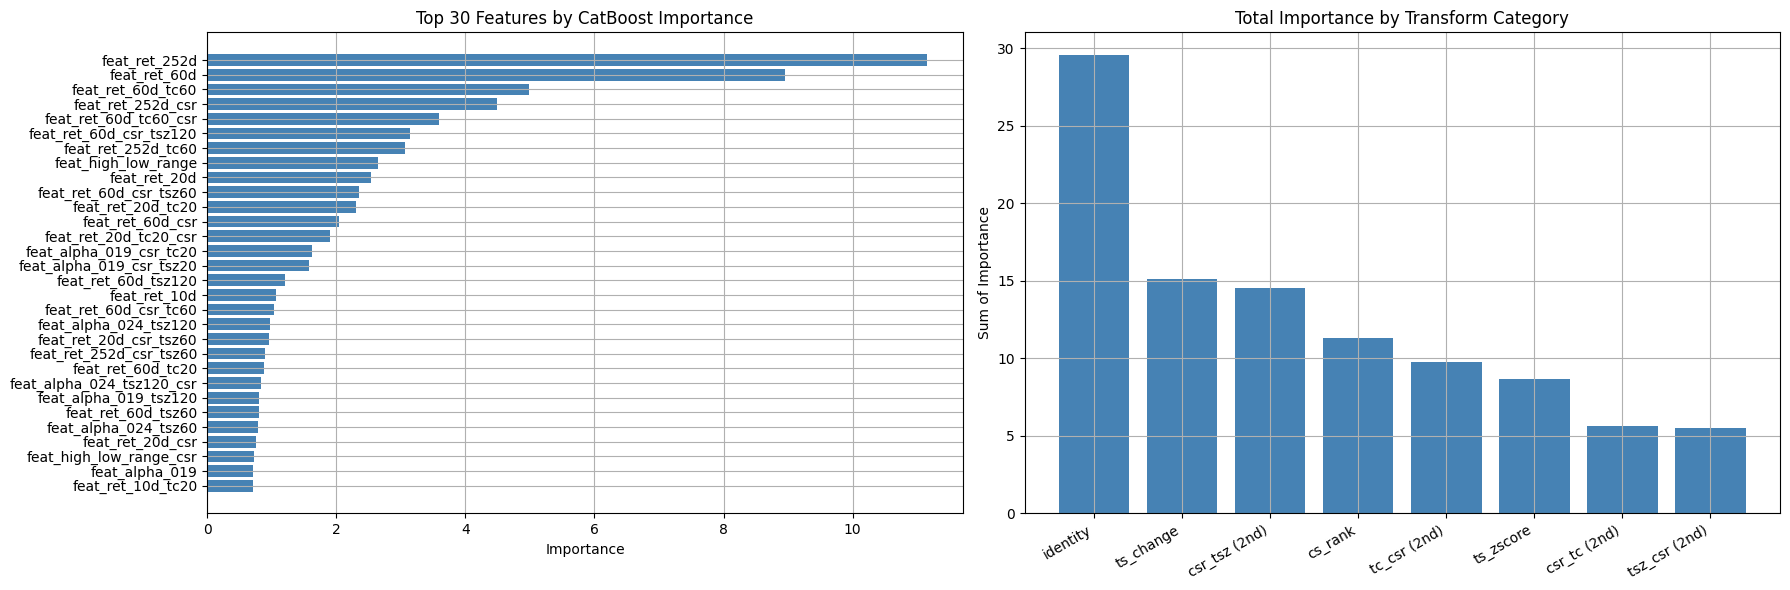


Importance by source:
source
ohlcv          77.132900
alpha101       21.403961
cross_combo     1.463139


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Top 30 features bar chart
top30 = fi_df.head(30)
axes[0].barh(top30["feature"][::-1], top30["importance"][::-1], color="steelblue")
axes[0].set_title("Top 30 Features by CatBoost Importance")
axes[0].set_xlabel("Importance")

# Importance by category
cat_fi = fi_df.groupby("category")["importance"].sum().sort_values(ascending=False)
axes[1].bar(cat_fi.index, cat_fi.values, color="steelblue")
axes[1].set_title("Total Importance by Transform Category")
axes[1].set_xticklabels(cat_fi.index, rotation=30, ha="right")
axes[1].set_ylabel("Sum of Importance")

plt.tight_layout()
plt.show()

# Source breakdown
src_fi = fi_df.groupby("source")["importance"].sum().sort_values(ascending=False)
print("\nImportance by source:")
print(src_fi.to_string())

## 9. 与 v1 Baseline 对比

In [18]:
v1_path = PROJECT_ROOT / "sp500_relative_alpha/artifacts/model_runs/xgb_h20_full52_primary_v1/summary.json"
with open(v1_path) as f:
    v1 = json.load(f)

v1_row = v1["horizon_summary"][0]
v2_row = horizon_summary[horizon_summary["horizon"] == HORIZON].iloc[0]

comparison = pd.DataFrame([
    {
        "version":       "v1  XGBoost  (52 Alpha101)",
        "mean_rank_ic":  v1_row["mean_rank_ic"],
        "positive_rate": v1_row["positive_rate"],
        "icir":          v1_row["icir"],
        "hac_t_stat":    v1_row["hac_t_stat"],
        "p_one_sided":   v1_row["p_value_one_sided"],
        "feature_count": v1["feature_count"],
    },
    {
        "version":       f"v2  CatBoost ({len(feat_cols)} features)",
        "mean_rank_ic":  v2_row["mean_rank_ic"],
        "positive_rate": v2_row["positive_rate"],
        "icir":          v2_row["icir"],
        "hac_t_stat":    v2_row["hac_t_stat"],
        "p_one_sided":   v2_row["p_value_one_sided"],
        "feature_count": len(feat_cols),
    },
])
print(comparison.to_string(index=False))

                     version  mean_rank_ic  positive_rate     icir  hac_t_stat  p_one_sided  feature_count
  v1  XGBoost  (52 Alpha101)      0.016468       0.542857 0.114307    1.304417     0.096046             52
v2  CatBoost (1327 features)      0.019469       0.519048 0.106496    1.145028     0.126099           1327


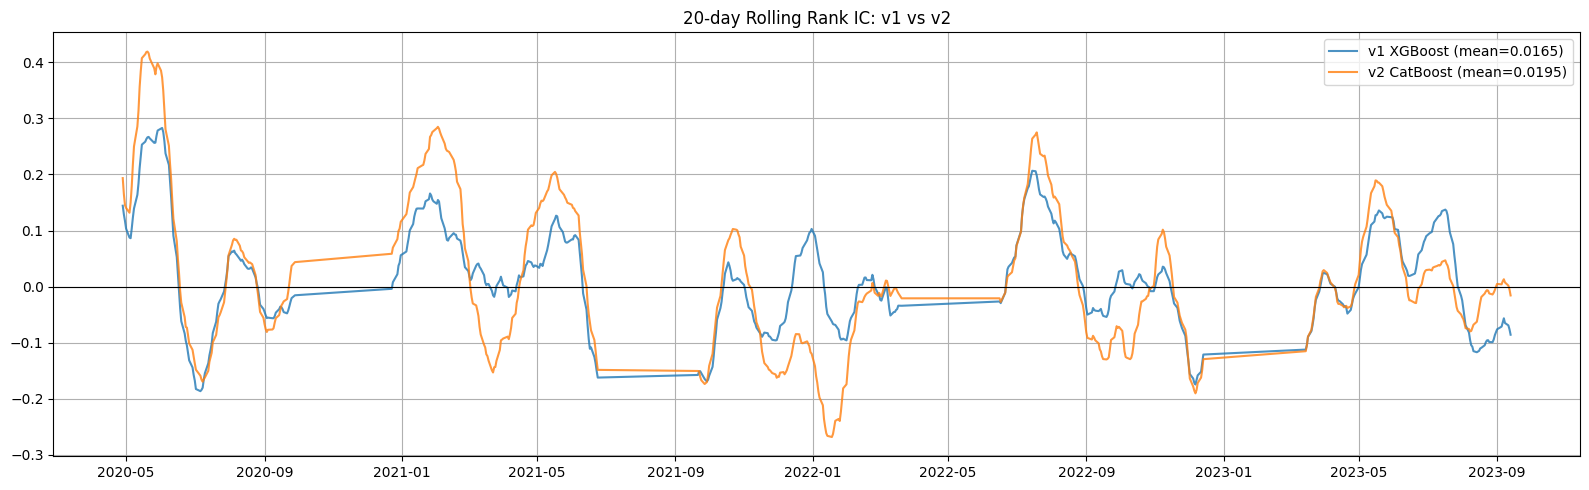

In [19]:
# 每日 IC 对比：v1 vs v2
v1_daily = pd.read_csv(
    PROJECT_ROOT / "sp500_relative_alpha/artifacts/model_runs/xgb_h20_full52_primary_v1/daily_rank_ic.csv"
)
v1_daily["signal_date"] = pd.to_datetime(v1_daily["signal_date"])
v1_ic = v1_daily[v1_daily["horizon"] == HORIZON].set_index("signal_date")["rank_ic"]
v2_ic = panel[panel["horizon"] == HORIZON].set_index("signal_date")["rank_ic"]

common_dates = v1_ic.index.intersection(v2_ic.index)

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(common_dates, v1_ic.loc[common_dates].rolling(20).mean(),
        label=f"v1 XGBoost (mean={v1_ic.mean():.4f})", alpha=0.8)
ax.plot(common_dates, v2_ic.loc[common_dates].rolling(20).mean(),
        label=f"v2 CatBoost (mean={v2_ic.loc[common_dates].mean():.4f})", alpha=0.8)
ax.axhline(0, color="k", lw=0.8)
ax.set_title("20-day Rolling Rank IC: v1 vs v2")
ax.legend()
plt.tight_layout()
plt.show()

## 10. Rolling Window vs Expanding Window 对比

**动机**：fold_003（2021H2-2022，加息周期）IC=-0.067，模型用 2015-2021 牛市数据训练，对制度转换失效。
滚动窗口（2年）只看近期数据，对 regime change 更敏感。

对比维度：
- 训练窗口：expanding（全历史）vs rolling（近 2 年）
- 每个 fold 的 train_start 和 train_end
- fold_003 重点观察

In [20]:
from sp500_relative_alpha.folds import build_round1_rolling_walk_forward_folds

ROLLING_WINDOW_DAYS = 2 * 252  # 2 years

rolling_folds = build_round1_rolling_walk_forward_folds(signal_dates, rolling_window_days=ROLLING_WINDOW_DAYS)
validate_fold_label_windows(h_samples, rolling_folds)

print(f"=== Expanding folds ({len(folds)} total) ===")
for f in folds:
    print(f"  {f.fold_id}: train [{f.train_start.date()}→{f.train_end.date()}]  "
          f"n_train={f.n_train_signal_dates}  test [{f.test_start.date()}→{f.test_end.date()}]")

print(f"\n=== Rolling folds (window={ROLLING_WINDOW_DAYS}d, {len(rolling_folds)} total) ===")
for f in rolling_folds:
    print(f"  {f.fold_id}: train [{f.train_start.date()}→{f.train_end.date()}]  "
          f"n_train={f.n_train_signal_dates}  test [{f.test_start.date()}→{f.test_end.date()}]")

=== Expanding folds (5 total) ===
  fold_001: train [2015-12-31→2020-01-02]  n_train=1008  test [2020-03-31→2020-09-28]
  fold_002: train [2015-12-31→2020-09-28]  n_train=1194  test [2020-12-23→2021-06-24]
  fold_003: train [2015-12-31→2021-06-24]  n_train=1380  test [2021-09-21→2022-03-21]
  fold_004: train [2015-12-31→2022-03-21]  n_train=1566  test [2022-06-16→2022-12-14]
  fold_005: train [2015-12-31→2022-12-14]  n_train=1752  test [2023-03-15→2023-09-13]

=== Rolling folds (window=504d, 5 total) ===
  fold_001: train [2018-01-02→2020-01-02]  n_train=504  test [2020-03-31→2020-09-28]
  fold_002: train [2018-09-27→2020-09-28]  n_train=504  test [2020-12-23→2021-06-24]
  fold_003: train [2019-06-26→2021-06-24]  n_train=504  test [2021-09-21→2022-03-21]
  fold_004: train [2020-03-23→2022-03-21]  n_train=504  test [2022-06-16→2022-12-14]
  fold_005: train [2020-12-15→2022-12-14]  n_train=504  test [2023-03-15→2023-09-13]


In [21]:
print("Running walk-forward predictions (rolling window)...")
predictions_rolling = run_walk_forward_predictions(
    h_samples,
    rolling_folds,
    lambda: CatBoostRegressorPredictor(cb_config),
    config=prediction_config,
)
print(f"Prediction rows: {len(predictions_rolling):,}")

Running walk-forward predictions (rolling window)...
Prediction rows: 310,547


In [22]:
panel_r, fold_summary_r, horizon_summary_r = evaluate_oos_rank_ic(predictions_rolling, rolling_folds, RankICConfig())

row_r = horizon_summary_r[horizon_summary_r["horizon"] == HORIZON].iloc[0]

print("=== Fold-level Rank IC 对比 ===")
print(f"{'fold_id':10s}  {'expanding IC':>14s}  {'rolling IC':>11s}  {'diff':>7s}")
for (_, re), (_, rr) in zip(fold_summary.iterrows(), fold_summary_r.iterrows()):
    diff = rr["mean_rank_ic"] - re["mean_rank_ic"]
    print(f"{re['fold_id']:10s}  {re['mean_rank_ic']:14.4f}  {rr['mean_rank_ic']:11.4f}  {diff:+.4f}")

print("\n=== Overall H=20 ===")
row_e = horizon_summary[horizon_summary["horizon"] == HORIZON].iloc[0]
comparison2 = pd.DataFrame([
    {"window": "expanding (all history)", "mean_rank_ic": row_e["mean_rank_ic"],
     "positive_rate": row_e["positive_rate"], "icir": row_e["icir"],
     "hac_t_stat": row_e["hac_t_stat"], "p_one_sided": row_e["p_value_one_sided"]},
    {"window": f"rolling ({ROLLING_WINDOW_DAYS}d / ~2yr)", "mean_rank_ic": row_r["mean_rank_ic"],
     "positive_rate": row_r["positive_rate"], "icir": row_r["icir"],
     "hac_t_stat": row_r["hac_t_stat"], "p_one_sided": row_r["p_value_one_sided"]},
])
print(comparison2.to_string(index=False))

=== Fold-level Rank IC 对比 ===
fold_id       expanding IC   rolling IC     diff
fold_001            0.0776       0.0459  -0.0318
fold_002            0.0603       0.0138  -0.0465
fold_003           -0.0667      -0.0768  -0.0101
fold_004            0.0087      -0.0046  -0.0133
fold_005            0.0175       0.0042  -0.0133

=== Overall H=20 ===
                 window  mean_rank_ic  positive_rate      icir  hac_t_stat  p_one_sided
expanding (all history)      0.019469       0.519048  0.106496    1.145028     0.126099
  rolling (504d / ~2yr)     -0.003499       0.461905 -0.021141   -0.232818     0.592048


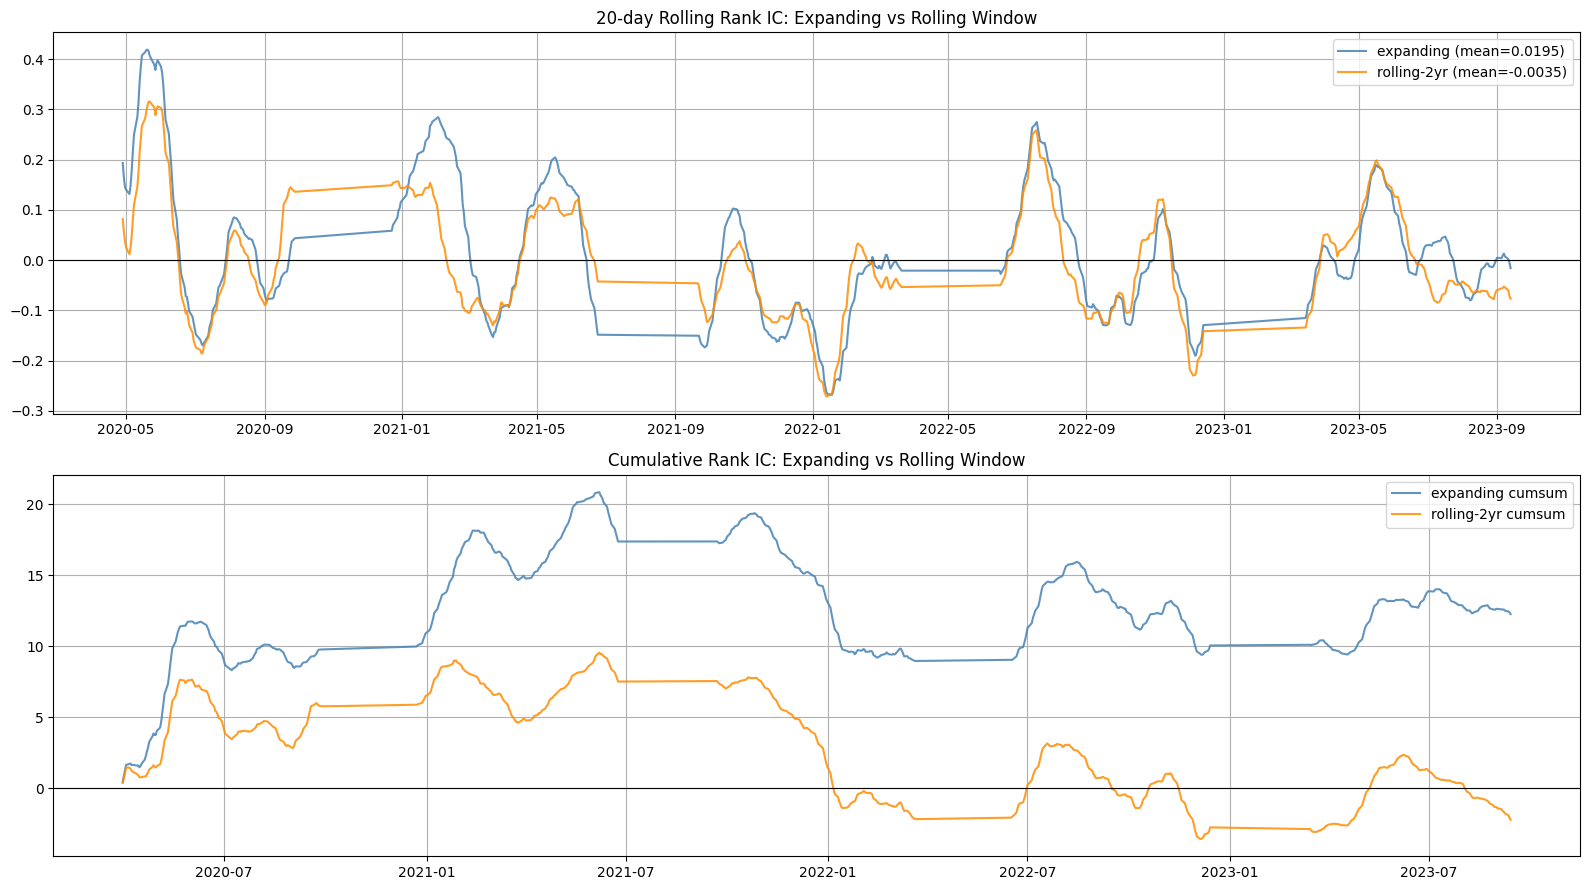

In [23]:
# 每日 IC 对比：expanding vs rolling
ic_e = panel[panel["horizon"] == HORIZON].set_index("signal_date")["rank_ic"]
ic_r = panel_r[panel_r["horizon"] == HORIZON].set_index("signal_date")["rank_ic"]

fig, axes = plt.subplots(2, 1, figsize=(16, 9))

# Rolling mean IC
for ic, label, color in [(ic_e, f"expanding (mean={ic_e.mean():.4f})", "steelblue"),
                          (ic_r, f"rolling-2yr (mean={ic_r.mean():.4f})", "darkorange")]:
    axes[0].plot(ic.index, ic.rolling(20).mean(), label=label, alpha=0.85, color=color)
axes[0].axhline(0, color="k", lw=0.8)
axes[0].set_title("20-day Rolling Rank IC: Expanding vs Rolling Window")
axes[0].legend()

# Cumulative IC
axes[1].plot(ic_e.index, ic_e.cumsum(), label="expanding cumsum", color="steelblue", alpha=0.85)
axes[1].plot(ic_r.index, ic_r.cumsum(), label="rolling-2yr cumsum", color="darkorange", alpha=0.85)
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_title("Cumulative Rank IC: Expanding vs Rolling Window")
axes[1].legend()

plt.tight_layout()
plt.show()

## 11. H=5 实验

Rolling window 全面输给 expanding，原因是训练数据量不足，方向放弃。

换一个维度：缩短 prediction horizon。H=5（1周） vs H=20（1月）：
- 标签噪声更高（单周收益波动大）但信号衰减快，模型必须学到更短期的 pattern
- fold 结构、特征完全复用，只换 label column
- 用同样的 expanding folds，直接对比

In [11]:
from sp500_relative_alpha.labels import build_round1_benchmark_relative_open_to_open_labels

HORIZON_5 = 5

# Build H=5 labels only (features are identical to H=20, reuse feat_cols from h_samples)
labels_h5 = build_round1_benchmark_relative_open_to_open_labels(daily_bars, horizons=[HORIZON_5])

# Feature snapshot: one row per (signal_date, symbol) — drop horizon-specific columns
feat_snapshot = h_samples[["signal_date", "symbol"] + feat_cols].drop_duplicates(["signal_date", "symbol"])

# Merge labels with features
h5_samples = labels_h5.merge(feat_snapshot, how="left", on=["signal_date", "symbol"], validate="many_to_one")
h5_samples = h5_samples[h5_samples["horizon"] == HORIZON_5].copy().reset_index(drop=True)

print(f"H=5 dataset rows : {len(h5_samples):,}")
print(f"Symbols          : {h5_samples['symbol'].nunique()}")
print(f"Signal dates     : {h5_samples['signal_date'].nunique()}")
print(f"Feature columns  : {len(feat_cols)}")
print(f"Label NaN rate   : {h5_samples[label_col].isna().mean():.2%}")

H=5 dataset rows : 1,225,807
Symbols          : 502
Signal dates     : 2515
Feature columns  : 1547
Label NaN rate   : 0.00%


In [14]:
# Folds: H=5 has more labelable signal_dates (earlier exit dates), regenerate from H=5 dates
signal_dates_h5 = h5_samples["signal_date"].drop_duplicates()
folds_h5 = build_round1_walk_forward_folds(signal_dates_h5)
validate_fold_label_windows(h5_samples, folds_h5)

print(f"H=5 folds: {len(folds_h5)}")
for f in folds_h5:
    print(f"  {f.fold_id}: train [{f.train_start.date()}→{f.train_end.date()}]  "
          f"test [{f.test_start.date()}→{f.test_end.date()}]")

print(f"\nRunning walk-forward predictions (H=5, CatBoost)...")

cb_config = CatBoostRegressorConfig()

prediction_config = WalkForwardPredictionConfig(feature_prefix="feat_", n_top_features=200)

n_top = prediction_config.n_top_features or len(feat_cols)
print(f"Feature pool: {len(feat_cols)}  →  per-fold top-{n_top} by IC  |  folds: {len(folds_h5)}")

predictions_h5 = run_walk_forward_predictions(
    h5_samples,
    folds_h5,
    lambda: CatBoostRegressorPredictor(cb_config),
    config=prediction_config,
)
print(f"Prediction rows: {len(predictions_h5):,}")

H=5 folds: 5
  fold_001: train [2015-12-31→2020-01-02]  test [2020-03-31→2020-09-28]
  fold_002: train [2015-12-31→2020-09-28]  test [2020-12-23→2021-06-24]
  fold_003: train [2015-12-31→2021-06-24]  test [2021-09-21→2022-03-21]
  fold_004: train [2015-12-31→2022-03-21]  test [2022-06-16→2022-12-14]
  fold_005: train [2015-12-31→2022-12-14]  test [2023-03-15→2023-09-13]

Running walk-forward predictions (H=5, CatBoost)...
Feature pool: 1547  →  per-fold top-200 by IC  |  folds: 5
Prediction rows: 310,547


In [15]:
panel_h5, fold_summary_h5, horizon_summary_h5 = evaluate_oos_rank_ic(predictions_h5, folds_h5, RankICConfig())
row_h5 = horizon_summary_h5[horizon_summary_h5["horizon"] == HORIZON_5].iloc[0]

print("=== Fold-level Rank IC: H=5 ===")
print(fold_summary_h5[["fold_id","mean_rank_ic","positive_rate","icir","hac_t_stat","p_value_one_sided"]].to_string(index=False))

print(f"\n=== H=5 Overall ===")
print(f"  mean Rank IC : {row_h5['mean_rank_ic']:.4f}")
print(f"  positive rate: {row_h5['positive_rate']:.2%}")
print(f"  ICIR         : {row_h5['icir']:.3f}")
print(f"  HAC t-stat   : {row_h5['hac_t_stat']:.3f}")
print(f"  p (one-sided): {row_h5['p_value_one_sided']:.4f}")
print(f"  bootstrap CI : [{row_h5['bootstrap_ci_lower']:.4f}, {row_h5['bootstrap_ci_upper']:.4f}]")

=== Fold-level Rank IC: H=5 ===
 fold_id  mean_rank_ic  positive_rate      icir  hac_t_stat  p_value_one_sided
fold_001      0.051956       0.539683  0.241485    1.605690           0.054171
fold_002     -0.001990       0.468254 -0.011751   -0.080935           0.532253
fold_003     -0.002638       0.476190 -0.013883   -0.090404           0.536017
fold_004      0.021685       0.523810  0.124797    0.863360           0.193970
fold_005      0.029535       0.587302  0.233158    1.651584           0.049310

=== H=5 Overall ===
  mean Rank IC : 0.0197
  positive rate: 51.90%
  ICIR         : 0.111
  HAC t-stat   : 1.603
  p (one-sided): 0.0544
  bootstrap CI : [-0.0043, 0.0394]


=== H=5 vs H=20 ===
       horizon  mean_rank_ic  positive_rate     icir  hac_t_stat  p_one_sided
H=20 (1 month)      0.019469       0.519048 0.106496    1.145028     0.126099
 H=5  (1 week)      0.019797       0.519048 0.104064    1.536758     0.062176

=== Per-fold IC: H=20 vs H=5 ===
fold_id       H=20 IC    H=5 IC     diff
fold_001       0.0776    0.0509  -0.0268
fold_002       0.0603    0.0031  -0.0572
fold_003      -0.0667   -0.0014  +0.0653
fold_004       0.0087    0.0149  +0.0062
fold_005       0.0175    0.0315  +0.0140


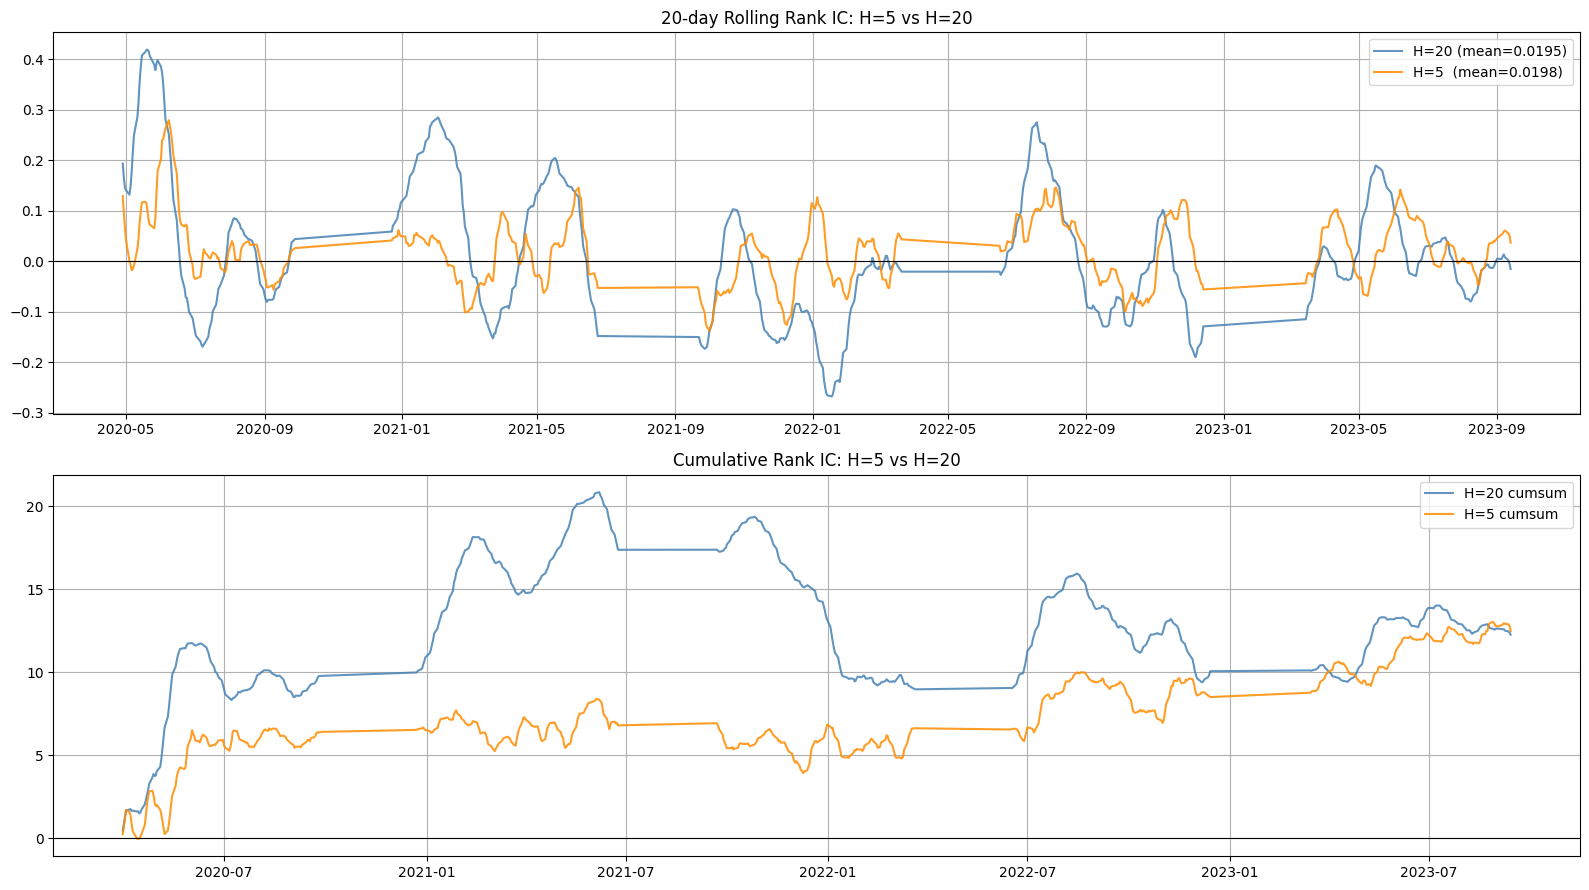

In [27]:
# H=5 vs H=20 综合对比
row_h20 = horizon_summary[horizon_summary["horizon"] == HORIZON].iloc[0]
comparison_h = pd.DataFrame([
    {"horizon": "H=20 (1 month)", "mean_rank_ic": row_h20["mean_rank_ic"],
     "positive_rate": row_h20["positive_rate"], "icir": row_h20["icir"],
     "hac_t_stat": row_h20["hac_t_stat"], "p_one_sided": row_h20["p_value_one_sided"]},
    {"horizon": "H=5  (1 week)",  "mean_rank_ic": row_h5["mean_rank_ic"],
     "positive_rate": row_h5["positive_rate"], "icir": row_h5["icir"],
     "hac_t_stat": row_h5["hac_t_stat"], "p_one_sided": row_h5["p_value_one_sided"]},
])
print("=== H=5 vs H=20 ===")
print(comparison_h.to_string(index=False))

# Per-fold comparison
print("\n=== Per-fold IC: H=20 vs H=5 ===")
print(f"{'fold_id':10s}  {'H=20 IC':>9s}  {'H=5 IC':>8s}  {'diff':>7s}")
for (_, r20), (_, r5) in zip(fold_summary.iterrows(), fold_summary_h5.iterrows()):
    diff = r5["mean_rank_ic"] - r20["mean_rank_ic"]
    print(f"{r20['fold_id']:10s}  {r20['mean_rank_ic']:9.4f}  {r5['mean_rank_ic']:8.4f}  {diff:+.4f}")

# Daily IC time series comparison
ic_h20 = panel[panel["horizon"] == HORIZON].set_index("signal_date")["rank_ic"]
ic_h5  = panel_h5[panel_h5["horizon"] == HORIZON_5].set_index("signal_date")["rank_ic"]

fig, axes = plt.subplots(2, 1, figsize=(16, 9))

for ic, label, color in [(ic_h20, f"H=20 (mean={ic_h20.mean():.4f})", "steelblue"),
                          (ic_h5,  f"H=5  (mean={ic_h5.mean():.4f})",  "darkorange")]:
    axes[0].plot(ic.index, ic.rolling(20).mean(), label=label, alpha=0.85, color=color)
axes[0].axhline(0, color="k", lw=0.8)
axes[0].set_title("20-day Rolling Rank IC: H=5 vs H=20")
axes[0].legend()

axes[1].plot(ic_h20.index, ic_h20.cumsum(), label="H=20 cumsum", color="steelblue", alpha=0.85)
axes[1].plot(ic_h5.index,  ic_h5.cumsum(),  label="H=5 cumsum",  color="darkorange", alpha=0.85)
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_title("Cumulative Rank IC: H=5 vs H=20")
axes[1].legend()

plt.tight_layout()
plt.show()

## 12. Excess Return Primitives（市场中性超额收益特征）

**新增 11 个 primitives**（加入 ohlcv_features.py）：
- `excess_ret_lag[1,2,5,10,20]d` — 个股超额收益的滞后值（短期反转信号）
- `excess_ret_mean[5,21,63]d` — 滚动均值（中期动量）
- `excess_ret_std[5,21,63]d` — 滚动标准差（alpha 稳定性）

这些特征会经过完整变换树（identity + cs_rank + ts_zscore + ts_change + 2阶）放大信息量。
重建 H=5 数据集并对比加入前后的 OOS Rank IC。

In [ ]:
# 重建完整 v2 数据集（含新 excess_ret primitives），H=5
import importlib
import sp500_relative_alpha.ohlcv_features as _ohlcv_mod
importlib.reload(_ohlcv_mod)
import sp500_relative_alpha.research_dataset as _ds_mod
importlib.reload(_ds_mod)
from sp500_relative_alpha.research_dataset import build_v2_research_dataset

dataset_v3 = build_v2_research_dataset(
    daily_bars,
    horizons=[HORIZON_5],
    transform_config=TRANSFORM_CONFIG,
)
h5_v3 = dataset_v3[dataset_v3["horizon"] == HORIZON_5].copy().reset_index(drop=True)
feat_cols_v3 = sorted(c for c in h5_v3.columns if c.startswith("feat_"))

# 新增的特征数量
new_primitives = [c for c in feat_cols_v3 if "excess_ret" in c]
print(f"Feature count: {len(feat_cols_v3)}  (+{len(feat_cols_v3) - len(feat_cols)} vs v2)")
print(f"New excess_ret derived features: {len(new_primitives)}")
print(f"  example: {new_primitives[:6]}")

In [ ]:
signal_dates_v3 = h5_v3["signal_date"].drop_duplicates()
folds_v3 = build_round1_walk_forward_folds(signal_dates_v3)
validate_fold_label_windows(h5_v3, folds_v3)

print(f"Running walk-forward (H=5, v3 with excess_ret)...")
predictions_v3 = run_walk_forward_predictions(
    h5_v3,
    folds_v3,
    lambda: CatBoostRegressorPredictor(cb_config),
    config=prediction_config,   # same: top-200 per-fold IC selection
)
print(f"Prediction rows: {len(predictions_v3):,}")

In [ ]:
panel_v3, fold_summary_v3, horizon_summary_v3 = evaluate_oos_rank_ic(predictions_v3, folds_v3, RankICConfig())
row_v3 = horizon_summary_v3[horizon_summary_v3["horizon"] == HORIZON_5].iloc[0]

# 三方对比：H=20 expanding | H=5 (无 excess_ret) | H=5 + excess_ret
print("=== H=5 + excess_ret vs 基线对比 ===")
comparison_v3 = pd.DataFrame([
    {"model": "H=20  CatBoost (v2)",          "mean_ic": row_h20["mean_rank_ic"], "icir": row_h20["icir"], "t_stat": row_h20["hac_t_stat"], "p": row_h20["p_value_one_sided"]},
    {"model": "H=5   CatBoost (v2, no exret)", "mean_ic": row_h5["mean_rank_ic"],  "icir": row_h5["icir"],  "t_stat": row_h5["hac_t_stat"],  "p": row_h5["p_value_one_sided"]},
    {"model": "H=5   CatBoost (v3, + exret)",  "mean_ic": row_v3["mean_rank_ic"],  "icir": row_v3["icir"],  "t_stat": row_v3["hac_t_stat"],  "p": row_v3["p_value_one_sided"]},
])
print(comparison_v3.to_string(index=False))

print("\n=== Per-fold IC: H=5 v2 vs v3 ===")
print(f"{'fold_id':10s}  {'H=5 v2':>9s}  {'H=5 v3':>9s}  {'diff':>7s}")
for (_, r2), (_, r3) in zip(fold_summary_h5.iterrows(), fold_summary_v3.iterrows()):
    diff = r3["mean_rank_ic"] - r2["mean_rank_ic"]
    print(f"{r2['fold_id']:10s}  {r2['mean_rank_ic']:9.4f}  {r3['mean_rank_ic']:9.4f}  {diff:+.4f}")

# 新特征在 fold_001 里的 IC 排名（看 excess_ret 有没有进入 top 选择）
fold0_v3 = folds_v3[0]
train_mask_v3 = fold_period_mask(h5_v3, fold0_v3, "train")
train_v3 = h5_v3.loc[train_mask_v3]
fold0_feats_v3 = list(_select_top_features_by_ic(train_v3, tuple(feat_cols_v3), label_col, 200))
exret_selected = [f for f in fold0_feats_v3 if "excess_ret" in f]
print(f"\nfold_001 top-200 中 excess_ret 特征: {len(exret_selected)}")
if exret_selected:
    print(f"  {exret_selected[:10]}")